# Embeddings Visualization

## Goal
Words live in vector space.
Similar words are close to each other.
This notebook visualizes that space to build intuition
about how meaning is represented numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 1. Manual Word Vectors
Before using pretrained embeddings.
let's build intuition with hand-crafted vectors.
Each dimension represents a concept.

In [4]:
# Manual embeddings - 3 dimensions: [royalty, gender, age]
word_vectors = {
    "king": [1.0, 1.0, 0.8],
    "queen": [1.0, 0.0, 0.8],
    "man": [0.0, 1.0, 0.5],
    "woman": [0.0, 0.0, 0.5],
    "boy": [0.0, 1.0, 0.0],
    "girl": [0.0, 0.0, 0.0],
    "prince": [0.8, 1.0, 0.2],
    "princess": [0.8, 0.0, 0.2],
}

words = list(word_vectors.keys())
vectors = np.array(list(word_vectors.values()))

print(f"{"Word":<12} {"royalty":>8} {"gender":>8} {"age":>8}")
print("-" * 40)
for word, vec in word_vectors.items():
    print(f"{word:<12} {vec[0]:>8.1f} {vec[1]:>8.1f} {vec[2]:>8.1f}")

Word          royalty   gender      age
----------------------------------------
king              1.0      1.0      0.8
queen             1.0      0.0      0.8
man               0.0      1.0      0.5
woman             0.0      0.0      0.5
boy               0.0      1.0      0.0
girl              0.0      0.0      0.0
prince            0.8      1.0      0.2
princess          0.8      0.0      0.2


## 2. Visualize in 2D with PCA
3D cevtors projected to 2D for visualization.

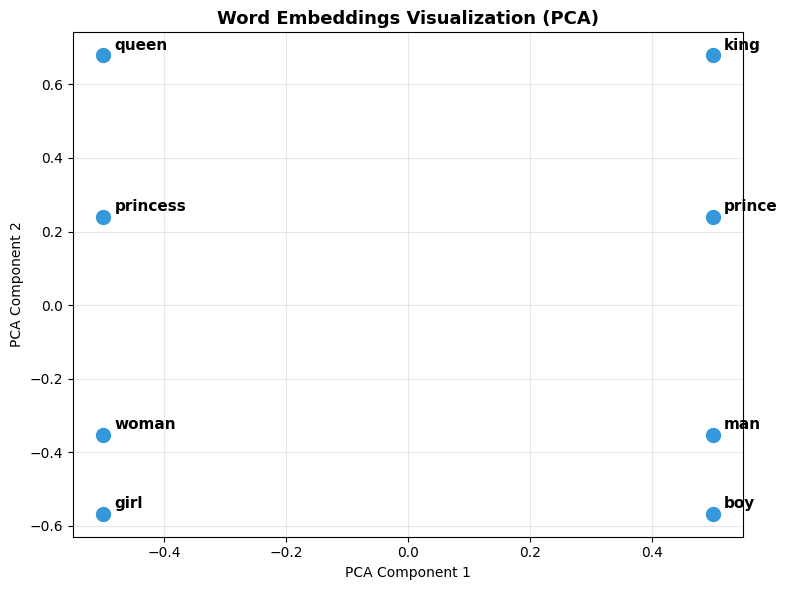

In [9]:
# Reduce to 2D with PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color="#3498db", s=100, zorder=5)

for i, word in enumerate(words):
    ax.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Word Embeddings Visualization (PCA)", fontsize=13, fontweight="bold")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("embeddings_visualization.png", dpi=300)
plt.show()

## 3. Key Observations

The plot reveals clear structure in the vector space:

- **Horizontal axis (PCA 1)**: separates male (right) from female (left)
- **Vertical axis (PCA 2)**: separates royalty (top) from commoner (bottom)

This is the core idea behind word embeddings:
similar words cluster together, and relationships become geometric.

## Key Insight
king - man + woman = queen
This famous analogy works because gender and royalty
are encoded as separate direction in vector space.

Real embedding (Word2Vec, GloVe) learn these dimensions
automatically from billions of words - without any manual labeling.

## Next 
How do we measure the distance between words in vector space?
-> 05_cosine_similarity.ipynb